# 1. Real GDP
## (across US states)

## 1.1
### 1.1 Question 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
from pathlib import Path
from dotenv import load_dotenv, dotenv_values  
from states import STATES, REGION

In [50]:
# The API key is tested
api_key = os.getenv("FRED_API_KEY")

if api_key is None:
    print("API key not found")
else:
    print("API key is found")


API key is found


In [51]:
# Testing whether states.py is imported correctly
print("Number of states: ",len(STATES))
print(STATES[:5])

Number of states:  50
['AL', 'AK', 'AZ', 'AR', 'CA']


In [52]:

# Setting up a method for downloading data from FRED API

from unittest import result


from unittest import result


FRED_URL = "https://api.stlouisfed.org/fred/series/observations"
# Defining the function for downloading data.
def download_fred_data(series_id):
    parameters = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json"
    }
    response = requests.get(
        FRED_URL,
        params=parameters,
        timeout=30
    )

    if response.status_code != 200:
        print(
            f"Fejl ved hentning af {series_id}:",
            response.status_code
        )
        print(response.text)

        return pd.Series(
            dtype="float64",
            name=series_id
        )
    observations = response.json()["observations"]

    data = pd.DataFrame(observations)

    data["year"] = pd.to_datetime(
        data["date"]
    ).dt.year

    data["value"] = pd.to_numeric(
        data["value"],
        errors="coerce"
    )

    result = data.set_index("year")["value"]

    result.name = series_id

    return result

In [53]:
alabama_gdp = download_fred_data("ALRGSP")

display(alabama_gdp.head())
display(alabama_gdp.tail())

year
1997    154700.0
1998    160396.4
1999    166531.8
2000    168695.3
2001    168448.3
Name: ALRGSP, dtype: float64

year
2021    233951.1
2022    239846.6
2023    248313.7
2024    255629.4
2025    260648.0
Name: ALRGSP, dtype: float64

In [54]:
def download_all_states(suffix):
    downloaded_series = {}

    for number, state in enumerate(
        STATES,
        start=1
    ):
        series_id = f"{state}{suffix}"

        print(
            f"{number}/{len(STATES)}: "
            f"Henter {series_id}"
        )

        downloaded_series[state] = (
            download_fred_data(series_id)
        )

    result = pd.DataFrame(downloaded_series)

    return result.sort_index()

In [55]:
gdp = download_all_states("RGSP")
population = download_all_states("POP")

print("GDP-format:", gdp.shape)
display(gdp.head())

print("Population-format:", population.shape)
display(population.head())

1/50: Henter ALRGSP
2/50: Henter AKRGSP
3/50: Henter AZRGSP
4/50: Henter ARRGSP
5/50: Henter CARGSP
6/50: Henter CORGSP
7/50: Henter CTRGSP
8/50: Henter DERGSP
9/50: Henter FLRGSP
10/50: Henter GARGSP
11/50: Henter HIRGSP
12/50: Henter IDRGSP
13/50: Henter ILRGSP
14/50: Henter INRGSP
15/50: Henter IARGSP
16/50: Henter KSRGSP
17/50: Henter KYRGSP
18/50: Henter LARGSP
19/50: Henter MERGSP
20/50: Henter MDRGSP
21/50: Henter MARGSP
22/50: Henter MIRGSP
23/50: Henter MNRGSP
24/50: Henter MSRGSP
25/50: Henter MORGSP
26/50: Henter MTRGSP
27/50: Henter NERGSP
28/50: Henter NVRGSP
29/50: Henter NHRGSP
30/50: Henter NJRGSP
31/50: Henter NMRGSP
32/50: Henter NYRGSP
33/50: Henter NCRGSP
34/50: Henter NDRGSP
35/50: Henter OHRGSP
36/50: Henter OKRGSP
37/50: Henter ORRGSP
38/50: Henter PARGSP
39/50: Henter RIRGSP
40/50: Henter SCRGSP
41/50: Henter SDRGSP
42/50: Henter TNRGSP
43/50: Henter TXRGSP
44/50: Henter UTRGSP
45/50: Henter VTRGSP
46/50: Henter VARGSP
47/50: Henter WARGSP
48/50: Henter WVRGSP
4

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,154700.0,41071.0,180293.9,87180.3,1441226.4,189445.6,205965.2,51267.0,603988.6,351183.9,...,27116.2,226832.8,860046.9,86283.5,21372.2,319992.6,281522.2,60364.6,222978.5,24257.7
1998,160396.4,40263.7,197492.1,89905.3,1538612.3,206449.1,212255.0,56487.0,634032.3,377705.9,...,28772.1,240963.4,920059.6,91312.7,22266.5,338931.5,299817.0,61725.7,232087.1,24804.7
1999,166531.8,39783.1,214293.9,94756.9,1655438.5,221040.8,218860.0,60866.2,664152.0,404465.2,...,30038.3,248457.5,957247.2,95206.8,23561.7,356391.8,322721.6,63691.7,242026.0,25866.8
2000,168695.3,38428.1,224729.3,95509.8,1784320.6,238739.3,233874.2,63388.8,693837.3,417713.5,...,32124.9,251030.2,989904.9,98648.5,24844.6,372914.1,325857.6,63364.6,248572.0,26614.2
2001,168448.3,40014.4,230885.6,95528.7,1784567.7,242650.1,236338.1,65724.8,714638.0,422731.6,...,32396.9,250311.4,1020517.0,100244.3,25681.8,386444.7,317860.6,63599.8,252941.8,28338.1


Population-format: (126, 50)


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1900,1830.0,NaN,124.0,1314.0,1490.0,543.0,910.0,185.0,530.0,2220.0,...,403.0,2023.0,3055.0,277.0,344.0,1858.0,523.0,959.0,2072.0,93.0
1901,1907.0,NaN,131.0,1341.0,1550.0,581.0,931.0,187.0,544.0,2263.0,...,418.0,2041.0,3132.0,284.0,347.0,1887.0,583.0,972.0,2109.0,100.0
1902,1935.0,NaN,138.0,1360.0,1623.0,621.0,952.0,188.0,565.0,2305.0,...,431.0,2060.0,3210.0,292.0,349.0,1894.0,651.0,1000.0,2141.0,105.0
1903,1957.0,NaN,144.0,1384.0,1702.0,652.0,972.0,190.0,587.0,2346.0,...,437.0,2082.0,3291.0,299.0,350.0,1890.0,719.0,1037.0,2171.0,108.0
1904,1978.0,NaN,151.0,1419.0,1792.0,659.0,987.0,192.0,599.0,2387.0,...,452.0,2086.0,3374.0,308.0,353.0,1889.0,782.0,1064.0,2202.0,111.0


### 1.1 Question 2

In [58]:
common_years = gdp.index.intersection(
    population.index
)
gdp_common = gdp.loc[common_years].copy()
population_common = population.loc[
    common_years
].copy()

print(
    "Years in common before removal "
    "of incomplete states:",
    len(common_years)
)

print(
    "First common year:",
    common_years.min()
)

print(
    "Last common year:",
    common_years.max()
)

Years in common before removal of incomplete states: 29
First common year: 1997
Last common year: 2025


In [64]:
complete_gdp = gdp_common.notna().all(
    axis=0
)

complete_population = (
    population_common.notna().all(axis=0)
)

complete_states = (
    complete_gdp
    & complete_population
)
removed_states = complete_states[
    ~complete_states
].index.tolist()

gdp_clean = gdp_common.loc[
    :,
    complete_states
].copy()

population_clean = population_common.loc[
    :,
    complete_states
].copy()

print("Number of years:", len(gdp_clean.index))
print("Number of states:", len(gdp_clean.columns))
print("Removed states:", removed_states)

assert gdp_clean.index.equals(
    population_clean.index
)

assert gdp_clean.columns.equals(
    population_clean.columns
)

assert not gdp_clean.isna().any().any()

assert not population_clean.isna().any().any()

print("No missing values")

Number of years: 29
Number of states: 50
Removed states: []
No missing values


### 1.1 Question 3

In [67]:
y = 1000 * gdp_clean / population_clean

y.index.name = "year"
y.columns.name = "state"

print("Antal år:", y.shape[0])
print("Antal stater:", y.shape[1])

display(y)



Antal år: 29
Antal stater: 50


state,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,35807.856017,67457.123805,39605.821967,34540.435110,44733.982939,48684.486108,63014.935839,69748.742898,41134.250699,46911.500176,...,37102.024341,42174.514399,44434.405916,41775.745777,36306.218308,47526.867411,50234.997381,33247.961542,42878.542989,50533.611371
1998,36863.947606,65447.615023,42314.201621,35420.860909,47077.134837,52015.826788,64858.950003,75916.652555,42529.012498,49460.461189,...,39371.282272,44354.433604,46674.180385,43470.604533,37702.830612,49921.971948,52711.999932,34070.822349,44443.046546,51671.614120
1999,38109.166834,64218.079096,44847.009375,37139.571517,49945.163875,54495.451702,66684.318338,80773.895942,43950.848785,51932.811521,...,40972.511127,45309.731770,47756.958006,44701.469972,39683.531512,51854.555973,56063.474824,35248.609795,46096.274488,53933.886848
2000,37890.553669,61194.847467,43547.244441,35656.771403,52498.582072,55175.331373,68549.087470,80609.074828,43236.432557,50771.619813,...,42502.024227,44011.670280,47263.240816,43951.174915,40754.374051,52480.115939,55131.873516,35065.779534,46254.567595,53842.201092
2001,37704.140491,63142.679505,43782.422868,35491.800142,51757.417416,54827.668563,68846.332550,82600.078673,43690.131776,50463.135060,...,42741.552458,43526.444806,47867.499715,43895.275899,41948.440356,53685.088358,53103.134426,35304.174732,46781.860367,57288.383668
2002,38488.163963,65237.873577,44152.305627,36422.490333,52234.391512,54271.685010,67743.366171,79018.791345,44714.258237,50225.298816,...,47072.445462,44607.670433,48066.794758,44230.659214,43095.531342,53554.165141,53198.700207,35706.879419,47375.431622,57800.634778
2003,39533.775020,63593.629996,46048.337279,37781.633696,53762.206105,54323.682656,67938.080598,78626.606504,45979.198528,50920.229675,...,47322.937848,45758.892386,47757.051211,44416.574123,44586.458377,54910.202652,53676.118487,35925.056351,48500.812983,59204.334863
2004,41916.808531,65040.210167,46880.937739,39488.799812,55004.042775,54659.800967,72275.173379,81530.158172,47885.820977,52598.032307,...,48827.615927,47635.475956,49619.896345,46352.359697,46762.808104,56416.315802,54291.725775,36377.569727,49947.606341,60459.118533
2005,43163.001485,66582.302015,48604.633917,40434.080509,56998.555569,56562.874577,73626.158982,78543.690469,49499.081887,53869.874731,...,50716.898799,48249.298913,50197.863099,48187.038469,47138.591309,58345.436681,57276.463270,37291.457474,50857.781754,63138.496607


### 1.1 Question 4

In [69]:
t_first = y.index.min()
t_last = y.index.max()

first_year_values = y.loc[t_first]
last_year_values = y.loc[t_last]

first_highest_state = first_year_values.idxmax()
first_highest_value = first_year_values.max()

first_lowest_state = first_year_values.idxmin()
first_lowest_value = first_year_values.min()

first_ratio = (
    first_highest_value
    / first_lowest_value
)

first_average = first_year_values.mean()

last_highest_state = last_year_values.idxmax()
last_highest_value = last_year_values.max()

last_lowest_state = last_year_values.idxmin()
last_lowest_value = last_year_values.min()

last_ratio = (
    last_highest_value
    / last_lowest_value
)

last_average = last_year_values.mean()

summary_1_1_4 = pd.DataFrame(
    {
        "Highest state": [
            first_highest_state,
            last_highest_state
        ],
        "Highest GDP per person": [
            first_highest_value,
            last_highest_value
        ],
        "Lowest state": [
            first_lowest_state,
            last_lowest_state
        ],
        "Lowest GDP per person": [
            first_lowest_value,
            last_lowest_value
        ],
        "Highest/lowest ratio": [
            first_ratio,
            last_ratio
        ],
        "Average across states": [
            first_average,
            last_average
        ]
    },
    index=[t_first, t_last]
)

summary_1_1_4.index.name = "Year"

summary_display = summary_1_1_4.copy()

numeric_columns = [
    "Highest GDP per person",
    "Lowest GDP per person",
    "Highest/lowest ratio",
    "Average across states"
]

summary_display[numeric_columns] = (
    summary_display[numeric_columns].round(2)
)

display(summary_display)

,Highest state,Highest GDP per person,Lowest state,Lowest GDP per person,Highest/lowest ratio,Average across states
Year,,,,,,
1997,DE,69748.74,ID,32062.68,2.18,44592.95
2025,NY,94701.99,MS,42434.03,2.23,64674.46


### 1.1 Question 5

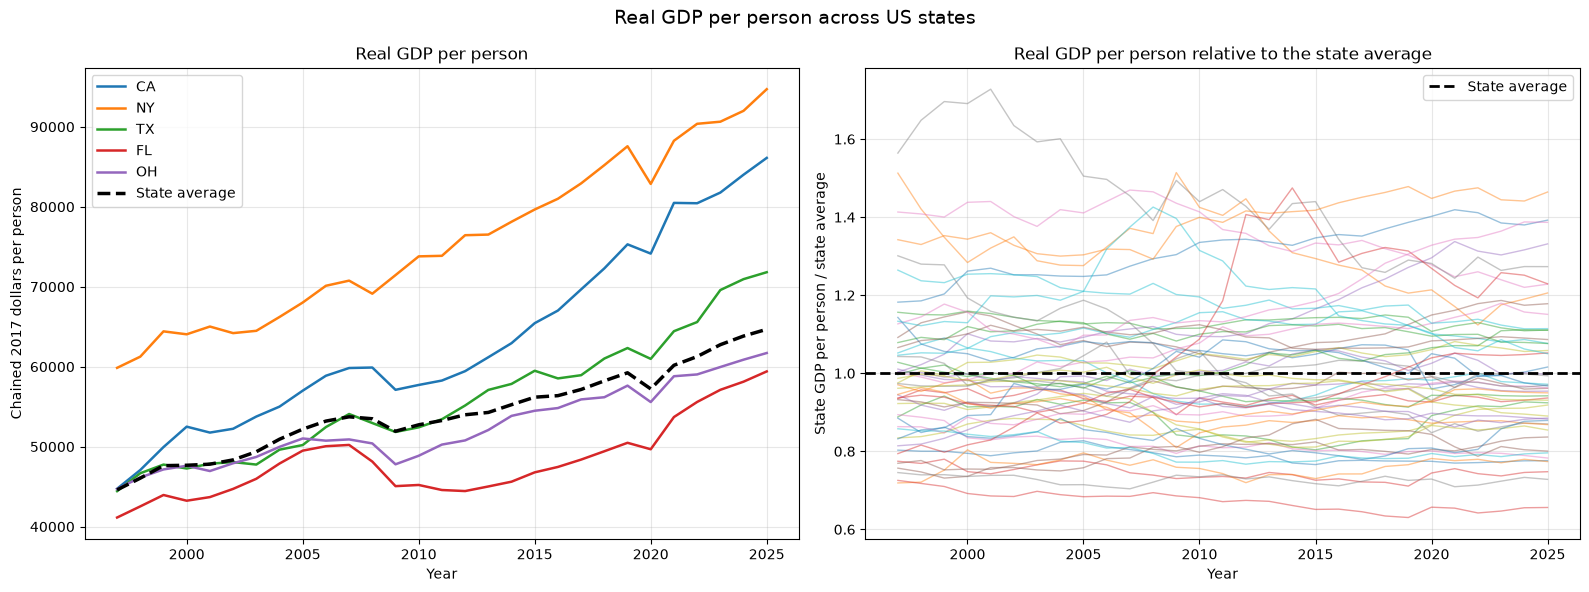

In [ ]:
selected_states = [
    "CA",
    "NY",
    "TX",
    "FL",
    "OH"
]

missing_selected_states = [
    state
    for state in selected_states
    if state not in y.columns
]

if missing_selected_states:
    raise ValueError(
        "these selected states are not in y: "
        f"{missing_selected_states}"
    )

average_across_states = y.mean(axis=1)

relative_y = y.div(
    average_across_states,
    axis=0
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# First panel
for state in selected_states:
    axes[0].plot(
        y.index,
        y[state],
        linewidth=1.8,
        label=state
    )

axes[0].plot(
    average_across_states.index,
    average_across_states,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label="State average"
)

axes[0].set_title(
    "Real GDP per person"
)

axes[0].set_xlabel("Year")

axes[0].set_ylabel(
    "Chained 2017 dollars per person"
)

axes[0].legend()
axes[0].grid(alpha=0.3)

# Second panel
for state in relative_y.columns:
    axes[1].plot(
        relative_y.index,
        relative_y[state],
        linewidth=1,
        alpha=0.45
    )

axes[1].axhline(
    y=1,
    color="black",
    linestyle="--",
    linewidth=2,
    label="State average"
)

axes[1].set_title(
    "Real GDP per person relative to the state average"
)

axes[1].set_xlabel("Year")

axes[1].set_ylabel(
    "State GDP per person / state average"
)

axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(
    "Real GDP per person across US states",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 1.2
### 1.2 Question 1

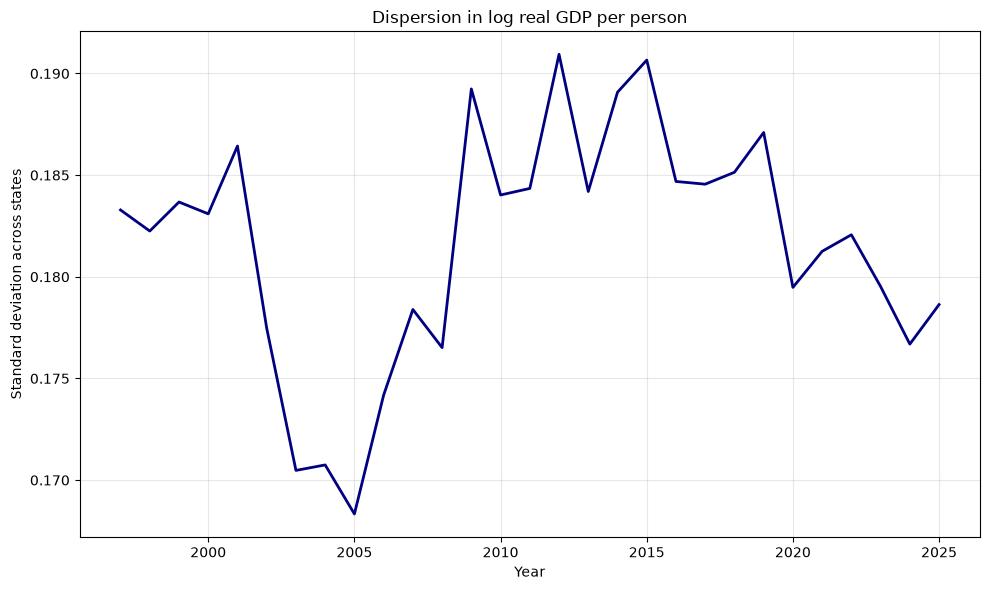

In [71]:
log_y = np.log(y)

dispersion = log_y.std(axis=1)
dispersion.name = "Standard deviation"
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    dispersion.index,
    dispersion,
    color="navy",
    linewidth=2
)

ax.set_title(
    "Dispersion in log real GDP per person"
)

ax.set_xlabel("Year")

ax.set_ylabel(
    "Standard deviation across states"
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Question 2

In [72]:
highest_dispersion_year = dispersion.idxmax()
lowest_dispersion_year = dispersion.idxmin()

dispersion_summary = pd.Series(
    {
        f"Value in {t_first}": (
            dispersion.loc[t_first]
        ),
        f"Value in {t_last}": (
            dispersion.loc[t_last]
        ),
        "Highest year": (
            highest_dispersion_year
        ),
        "Highest value": (
            dispersion.loc[
                highest_dispersion_year
            ]
        ),
        "Lowest year": (
            lowest_dispersion_year
        ),
        "Lowest value": (
            dispersion.loc[
                lowest_dispersion_year
            ]
        )
    }
)

display(dispersion_summary.round(4))

Value in 1997       0.1833
Value in 2025       0.1786
Highest year     2012.0000
Highest value       0.1909
Lowest year      2005.0000
Lowest value        0.1683
dtype: float64

### 1.2 Question 3

## 1.3 Question 3 - Growth and convergence

For each state, the average annual growth rate is calculated between the first and last years. The relationship between initial real GDP per person and subsequent growth is then examined.


### 1.3.1 - Average annual growth and scatterplot

The average annual growth rate is measured in log points per year. The scatterplot compares this growth rate with log real GDP per person in the first year.


In [ ]:
T = t_last - t_first

initial_log_income = np.log(y.loc[t_first])
final_log_income = np.log(y.loc[t_last])

growth = (
    final_log_income - initial_log_income
) / T

growth.name = "Average annual growth"

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    initial_log_income,
    growth,
    color="steelblue",
    alpha=0.75
)

ax.set_title("Initial income and subsequent growth")
ax.set_xlabel(f"Log real GDP per person in {t_first}")
ax.set_ylabel("Average annual growth in log points")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 1.3.2 - Fitted line and correlation

A straight line is fitted using `np.polyfit`. The intercept, slope and correlation between initial income and growth are reported below.


In [ ]:
b, a = np.polyfit(
    initial_log_income,
    growth,
    1
)

correlation = initial_log_income.corr(growth)

regression_results = pd.Series(
    {
        "Intercept a": a,
        "Slope b": b,
        "Correlation": correlation
    }
)

display(regression_results.round(6))

x_line = np.linspace(
    initial_log_income.min(),
    initial_log_income.max(),
    200
)

fitted_line = a + b * x_line

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    initial_log_income,
    growth,
    color="steelblue",
    alpha=0.75,
    label="States"
)

ax.plot(
    x_line,
    fitted_line,
    color="darkred",
    linewidth=2,
    label="Fitted line"
)

ax.set_title("Initial income and subsequent growth")
ax.set_xlabel(f"Log real GDP per person in {t_first}")
ax.set_ylabel("Average annual growth in log points")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 1.3.3 - States with the highest and lowest growth

The five states with the highest growth and the five states with the lowest growth are identified and labelled in the figure.


In [ ]:
highest_growth_states = growth.nlargest(5).index
lowest_growth_states = growth.nsmallest(5).index

print(
    "Five states with the highest growth:",
    highest_growth_states.tolist()
)

print(
    "Five states with the lowest growth:",
    lowest_growth_states.tolist()
)

states_to_label = highest_growth_states.union(
    lowest_growth_states
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    initial_log_income,
    growth,
    color="steelblue",
    alpha=0.75,
    label="States"
)

ax.plot(
    x_line,
    fitted_line,
    color="darkred",
    linewidth=2,
    label="Fitted line"
)

for state in states_to_label:
    ax.annotate(
        state,
        (
            initial_log_income.loc[state],
            growth.loc[state]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("Initial income and subsequent growth")
ax.set_xlabel(f"Log real GDP per person in {t_first}")
ax.set_ylabel("Average annual growth in log points")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 1.3.4 - Speed of convergence and half-life

The annual speed of convergence, lambda, and the half-life of an initial income gap are calculated from the estimated slope.


In [ ]:
convergence_term = 1 + b * T

if convergence_term <= 0:
    raise ValueError(
        "1 + bT must be positive to calculate lambda."
    )

lambda_convergence = (
    -np.log(convergence_term) / T
)

half_life = np.log(2) / lambda_convergence

convergence_results = pd.Series(
    {
        "Lambda": lambda_convergence,
        "Lambda in percent": 100 * lambda_convergence,
        "Half-life in years": half_life
    }
)

display(convergence_results.round(4))


### 1.3.5 - Interpretation

Describe how closely the points follow the fitted line. State whether the estimated relationship is negative or positive, whether it indicates convergence or divergence, and whether the relationship appears weak, moderate or strong based on the correlation and the figure.


## 1.4 Question 4 - Regional development

The states are grouped into the four Census regions using `REGION` from `states.py`.


### 1.4.1 - Regional averages and number of states

For each state, real GDP per person is divided by the average across all states in the same year. The relative values are then averaged across the states in each region.


In [ ]:
average_across_states = y.mean(axis=1)

relative_y = y.div(
    average_across_states,
    axis=0
)

state_regions = pd.Series(
    REGION,
    name="Region"
).reindex(y.columns)

if state_regions.isna().any():
    missing_regions = state_regions[
        state_regions.isna()
    ].index.tolist()

    raise ValueError(
        "These states do not have a region: "
        f"{missing_regions}"
    )

region_counts = (
    state_regions
    .value_counts()
    .sort_index()
)

regional_relative_y = (
    relative_y
    .T
    .groupby(state_regions)
    .mean()
    .T
)

display(
    region_counts.rename("Number of states")
)

display(regional_relative_y)


### 1.4.2 - Regional development over time

The four regional series are plotted against the year. A value above one indicates that a region is above the average across all states in that year.


In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))

for region in regional_relative_y.columns:
    ax.plot(
        regional_relative_y.index,
        regional_relative_y[region],
        linewidth=2,
        label=region
    )

ax.axhline(
    y=1,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="All-state average"
)

ax.set_title(
    "Regional real GDP per person relative "
    "to the state average"
)
ax.set_xlabel("Year")
ax.set_ylabel("Regional average / all-state average")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 1.4.3 - First year, last year and change

The relative regional values in the first and last years are reported together with the change between the two years. The region with the largest absolute movement is also identified.


In [ ]:
regional_summary = pd.DataFrame(
    {
        f"Value in {t_first}": (
            regional_relative_y.loc[t_first]
        ),
        f"Value in {t_last}": (
            regional_relative_y.loc[t_last]
        )
    }
)

regional_summary["Change"] = (
    regional_summary[f"Value in {t_last}"]
    - regional_summary[f"Value in {t_first}"]
)

regional_summary["Number of states"] = region_counts

display(regional_summary.round(4))

largest_movement_region = (
    regional_summary["Change"]
    .abs()
    .idxmax()
)

largest_change = regional_summary.loc[
    largest_movement_region,
    "Change"
]

if largest_change > 0:
    direction = "upward"
elif largest_change < 0:
    direction = "downward"
else:
    direction = "no change"

print(
    "Region with the largest movement:",
    largest_movement_region
)
print("Change:", round(largest_change, 4))
print("Direction:", direction)
